Note: If you get an error message the first time you run something you may have to clone the ThinkDSP library.  To do this go to "Runtime->reset all runtimes", then press the run button in the "Install" section to clone the dependency into your runtime.

# Install
Download the ThinkDSP library


In [ ]:
!git clone https://github.com/AllenDowney/ThinkDSP.git 

Cloning into 'ThinkDSP'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 2086 (delta 3), reused 15 (delta 3), pack-reused 2071
Receiving objects: 100% (2086/2086), 190.45 MiB | 31.48 MiB/s, done.
Resolving deltas: 100% (1108/1108), done.


*************************************************************************************************************
# Generation of sin wave

This is how it is possible to generate a sin wave.  

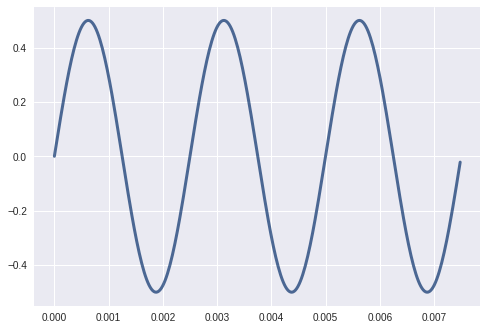

Writing sound.wav


In [ ]:
# This file shows how to generate a sine wave using the ThinkDSP library.
import sys
sys.path.insert(0, 'ThinkDSP/code/') 
import thinkdsp
import matplotlib.pyplot as pyplot
import IPython

# Generate wave
sin = thinkdsp.SinSignal(freq=400, amp=0.5) # Where freq is the frequency and amp is the amplitude of the sine wave
wave = sin.make_wave(duration=2, start=0, framerate=44100) # Turn the sin wave into an audio wave

# Plot wave
period = sin.period
segment = wave.segment(start=0, duration=period*3)
segment.plot()
pyplot.show()

# Play wave
wave.play()
IPython.display.Audio('sound.wav') # This is required on Google Colab due to compatibility issues


Challenges:
> Can you change it to a higher pitch? What about a lower pitch?  
> Can you increase the lenth of the sound?  

Consider this:
> What do you think will happen if multiple sin waves are played at the same time?



*************************************************************************************************************
 # Adding Waves Together
 

This is how 2 sin waves can be added together.
Look at the graph and see how to output wave changes when 2 sounds are added together

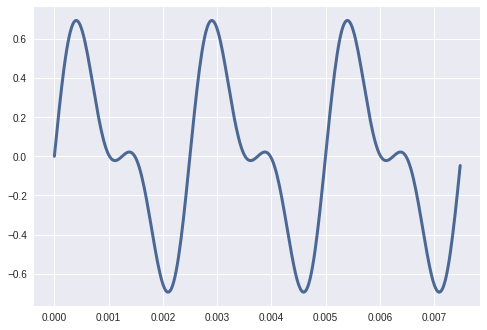

Writing sound.wav


In [ ]:
import sys
sys.path.insert(0, 'ThinkDSP/code/') 
import thinkdsp
import matplotlib.pyplot as pyplot
import IPython

# Generate wave
sin1 = thinkdsp.SinSignal(freq=400, amp=0.5)
sin2 = thinkdsp.SinSignal(freq=800, amp=0.3)
mix = sin1 + sin2 # Notice here how 2 waves can be added together
wave = mix.make_wave(duration=2, start=0, framerate=44100)

# Plot wave
period = mix.period
segment = wave.segment(start=0, duration=period*3)
segment.plot()
pyplot.show()

# Play wave
wave.play()
IPython.display.Audio('sound.wav')

Challenge:
> Can you add 3 waves together, what about 4, or 5?

Consider this:
> Do you think  there is a better way to graph this data?



*************************************************************************************************************
# Frequency Domain
Now we will take the previously generated sound and look at it in frequency domain.  This is where rather than seeing what the wave looks like we see the frequencies that make up the wave

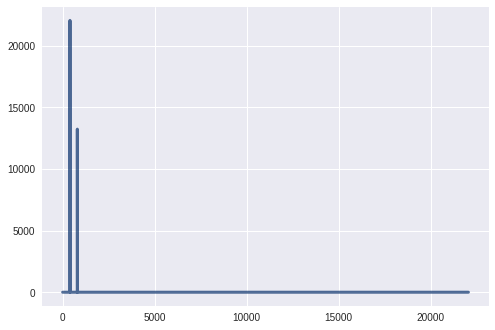

Writing sound.wav


In [ ]:
import sys
sys.path.insert(0, 'ThinkDSP/code/') 
import thinkdsp
import matplotlib.pyplot as pyplot
import IPython

# Generate wave
sin1 = thinkdsp.SinSignal(freq=400, amp=0.5)
sin2 = thinkdsp.SinSignal(freq=800, amp=0.3)
mix = sin1 + sin2 # Notice here how 2 waves can be added together
wave = mix.make_wave(duration=2, start=0, framerate=44100)

# Plot spectrum of wave
spectrum = wave.make_spectrum()
spectrum.plot()
pyplot.show()

# Play wave
wave.play()
IPython.display.Audio('sound.wav')

Challenge: 
> Can you increase the higher frequencies to have a higher amplitude?  
> What happens when you add more waves to the mix?  

Consider this:
> What do you think a frequency domain plot of a song would look like



*************************************************************************************************************
# Reading An Audio File

In [ ]:
!git clone https://github.com/Tyler-Hilbert/AudioProcessingInPythonWorkshop.git 

Cloning into 'AudioProcessingInPythonWorkshop'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 37 (delta 16), reused 33 (delta 12), pack-reused 0
Unpacking objects: 100% (37/37), done.


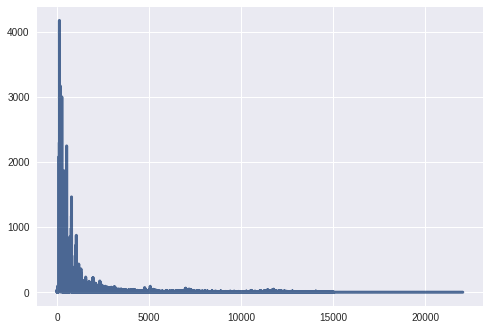

Writing sound.wav


In [ ]:
import sys
sys.path.insert(0, 'ThinkDSP/code/') 
import thinkdsp
import matplotlib.pyplot as pyplot
import IPython

# Read in audio file
# FIXME - will this work for non wav files
wave = thinkdsp.read_wave('AudioProcessingInPythonWorkshop/test.wav')

# Grab first 10 seconds of audio (you can ignore me)
clipLength = 10 # in seconds
index = 0
while (index < wave.ts.size and wave.ts[index] < clipLength):
	index += 1
# Remove extras
wave.ts = wave.ts[:index]
wave.ys = wave.ys[:index]

# Plot spectrum of audio file
spectrum = wave.make_spectrum()
spectrum.plot()
pyplot.show()

# Play audio file
wave.play()
IPython.display.Audio('sound.wav')

*************************************************************************************************************
# Filtering

Now we will apply a filter to the sound.  A low pass filter will remove high frequencies while a high pass filter will remove low frequencies.  Think of a low pass filter as increasing bass and a high pass filter as increasing treble.

This piece of code will apply a low pass filter.  Listen to how it sounds different, then compare how the frequencies changed from the last graph.





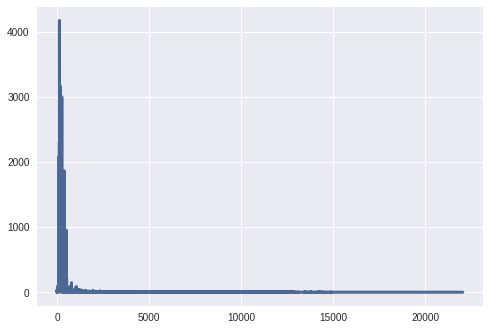

Writing sound.wav


In [ ]:
import sys
sys.path.insert(0, 'ThinkDSP/code/') 
import thinkdsp
import matplotlib.pyplot as pyplot
import IPython

# Read in audio file
wave = thinkdsp.read_wave('AudioProcessingInPythonWorkshop/test.wav')

# Grab first 10 seconds of audio (you can ignore me)
clipLength = 10 # in seconds
index = 0
while (index < wave.ts.size and wave.ts[index] < clipLength):
	index += 1
# Remove extras
wave.ts = wave.ts[:index]
wave.ys = wave.ys[:index]


# Filter
spectrum = wave.make_spectrum()
spectrum.low_pass(cutoff = 500, factor = .1)
#spectrum.high_pass(cutoff = 1500, factor = .1) # FIXME - Change back to low pass filter
filteredWave = spectrum.make_wave()

# Plot spectrum of audio file
spectrum = filteredWave.make_spectrum()
spectrum.plot()
pyplot.show()

# Play filtered audio file
filteredWave.play()
IPython.display.Audio('sound.wav')

Challenge:
> Try to decrease of increase the amount of "bass"
> Try to change the change of frequencies that are filtered out
> Change the low pass filter to a high pass filter (by switching the comments) and see how it changes

Consider this:
> Why do you think the high pass filter sounds poorly?

*************************************************************************************************************

I am assuming you have tried the high pass filter and noticed how bad it sounds, and the volume decreasing.  We will now fix this by adding the filtered sound back into the original sound. 

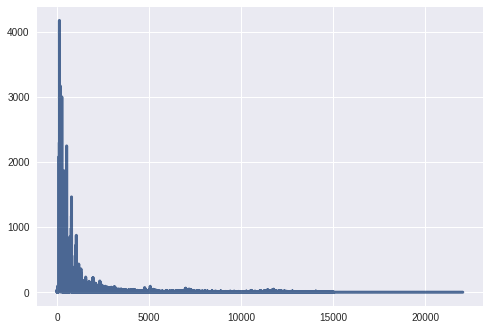

Writing sound.wav


ThinkDSP/code/thinkdsp.py:1125: UserWarning: Warning: normalizing before quantizing.
  warnings.warn('Warning: normalizing before quantizing.')


In [ ]:
import sys
sys.path.insert(0, 'ThinkDSP/code/') 
import thinkdsp
import matplotlib.pyplot as pyplot
import IPython

# Read in audio file
wave = thinkdsp.read_wave('AudioProcessingInPythonWorkshop/test.wav')

# Grab first 10 seconds of audio (you can ignore me)
clipLength = 10 # in seconds
index = 0
while (index < wave.ts.size and wave.ts[index] < clipLength):
	index += 1
# Remove extras
wave.ts = wave.ts[:index]
wave.ys = wave.ys[:index]


# Filter
spectrum = wave.make_spectrum()
spectrum.high_pass(cutoff = 1500, factor = .1) # FIXME - Change back to low pass filter
filteredWave = spectrum.make_wave()

# Add filtered wave to original wave
filteredWave.ys *= 10 # Increase the filtered wave's power so the treble effect is more noticable
combinedWave = filteredWave + wave

# Plot spectrum of audio file
spectrum = wave.make_spectrum()
spectrum.plot()
pyplot.show()

# Play filtered audio file
combinedWave.play()
IPython.display.Audio('sound.wav')

********************************************************
Try it with a different song by replacing the loaded wave from the previous examples (you'll need to run the "Extract wav from mp3" code to get the rock.wav file first):

In [ ]:
wave = thinkdsp.read_wave('AudioProcessingInPythonWorkshop/rock.wav') # Paste this into the previous examples

# Thanks For Attending
Special thanks to ThinkDSP and Fort Collins Data Science Meetup


# Extract wav from mp3

In [ ]:
  import subprocess

  subprocess.call(['ffmpeg', '-i', 'AudioProcessingInPythonWorkshop/rock.mp3',
                   'AudioProcessingInPythonWorkshop/rock.wav'])

0

view file system


In [ ]:
import subprocess

p = subprocess.Popen('ls', shell=True, stdout=subprocess.PIPE)
print(str(p.communicate()[0], 'utf-8'))

AudioProcessingInPythonWorkshop
sample_data
sound.wav
ThinkDSP

